# Single factor analysis

In [12]:
import pandas as pd
import numpy as np

In [13]:
train = pd.read_csv(r"C:\Users\niels\OneDrive\Dokumenter\Churn modelling\Churn-modelling\data\development_data.csv")

In [14]:
from python_modules.src.outlier_handler import cont_outliers

In [15]:
train = cont_outliers(train)

In [16]:
import pickle

In [17]:
with open(r"C:\Users\niels\OneDrive\Dokumenter\Churn modelling\Churn-modelling\pickle\cont_cat.pkl", "rb") as f:
    col_type = pickle.load(f)

In [18]:
col_type

{'continious': ['age',
  'total_orders',
  'total_spend_usd',
  'avg_order_value_usd',
  'days_since_last_purchase',
  'reviews_given',
  'avg_review_score',
  'wishlist_items'],
 'categorical': ['preferred_device',
  'membership_tier',
  'newsletter_subscribed',
  'acquisition_channel',
  'preferred_category',
  'returns_made',
  'preferred_payment_method',
  'country',
  'registration_date',
  'gender']}

In [19]:
def quantile_sorter(p, P):
    for s, q in P:
        if q >= p:
            return s

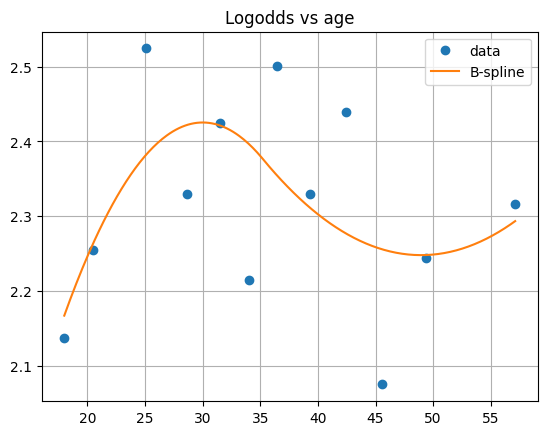

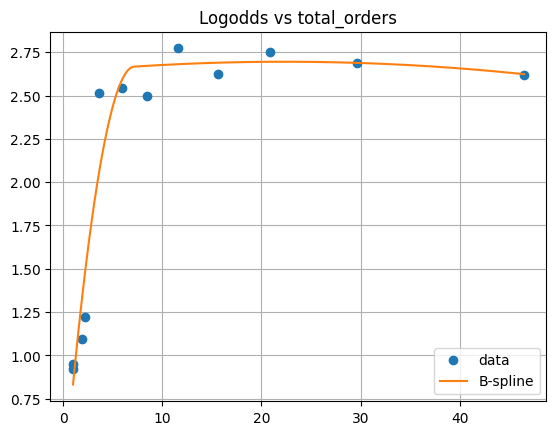

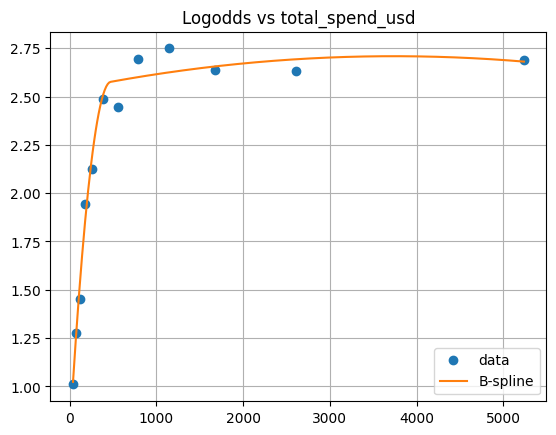

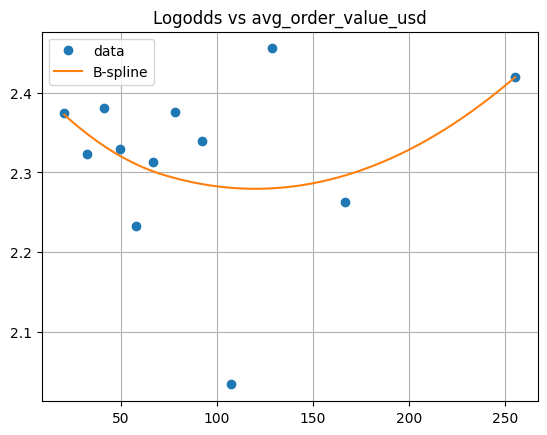

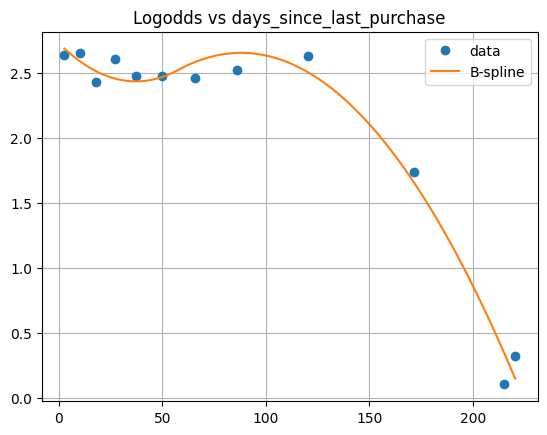

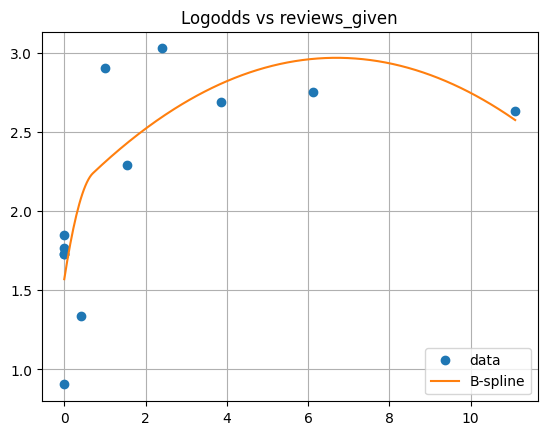

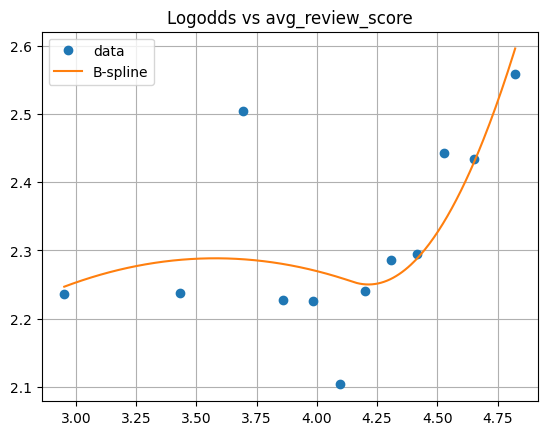

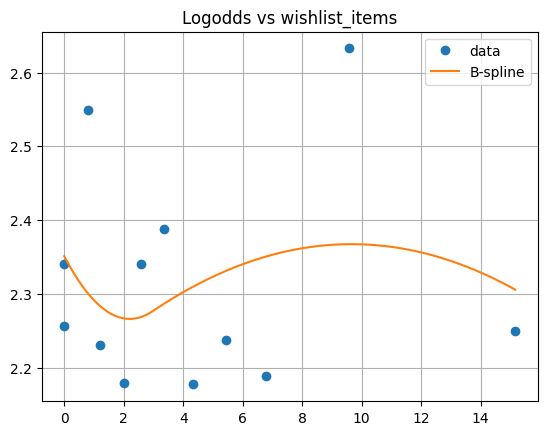

In [23]:
from scipy.interpolate import LSQUnivariateSpline
import matplotlib.pyplot as plt

splines = {}

for var in col_type["continious"]:
    train.sort_values(by = var, ascending=True, inplace=True)
    train["cumsum"] = train["churned"].cumsum()
    train["fractile"] = train["cumsum"]/train["churned"].sum()
    L = np.linspace(0, 1, round(train["churned"].sum()/50))
    L = list(L)
    L.remove(np.float64(0.0))
    L = list(enumerate(L))
    train["group"] = train["fractile"].apply(lambda p: quantile_sorter(p,L))
    agg_data = train.groupby("group").agg({var: "mean", "churned": "mean"})
    agg_data["logodds"] = -np.log(agg_data["churned"]/(1-agg_data["churned"]))
    # Specify the number of interior knots you want
    n_knots = 3
    knots = np.quantile(agg_data[var], np.linspace(0, 1, n_knots))[1:-1]
    spl = LSQUnivariateSpline(agg_data[var], agg_data["logodds"], t=knots, k=2)
    splines[var] = spl
    x_smooth = np.linspace(agg_data[var].min(), agg_data[var].max(), 300)
    plt.figure()
    plt.plot(agg_data[var], agg_data["logodds"], 'o', label='data')
    plt.plot(x_smooth, spl(x_smooth), label='B-spline')
    plt.title(f"Logodds vs {var}")
    plt.grid(True)
    plt.legend()

The variables:

* reviews_given
* days_since_last_purchase
* total_usd_spend
* total_orders

seems to have a reasonable relationship between -logodds of the churnrate and the variables that can be smoothed out.

In [24]:
del splines["wishlist_items"]
del splines["avg_review_score"]
del splines["avg_order_value_usd"]
del splines["age"]

In [25]:
with open(r"C:\Users\niels\OneDrive\Dokumenter\Churn modelling\Churn-modelling\pickle\logodds_splines.pkl", "wb") as file:
    pickle.dump(splines, file)

In [44]:
for var in splines.keys():
    train["logodds_" + var] = splines[var](train[var])

In [78]:
col_type["categorical"]

['preferred_device',
 'membership_tier',
 'newsletter_subscribed',
 'acquisition_channel',
 'preferred_category',
 'returns_made',
 'preferred_payment_method',
 'country',
 'registration_date',
 'gender']

In [84]:
for var in col_type["categorical"]:
    print(var)
    train["churn_count_" + var] = train.groupby(var)["churned"].transform("sum")
    train["total_count_" + var] = train.groupby(var)[var].transform("count")
    train["non_churn_count_" + var] = train["total_count_" + var] - train["churn_count_" + var]
    
    total_churned = train["churned"].sum()
    total_non_churned = len(train) - total_churned
    
    train["pct_churned_" + var] = train["churn_count_" + var] / total_churned
    train["pct_non_churned_" + var] = train["non_churn_count_" + var] / total_non_churned
    
    train["WoE_" + var] = np.log(train["pct_non_churned_" + var] / train["pct_churned_" + var])

preferred_device
membership_tier
newsletter_subscribed
acquisition_channel
preferred_category
returns_made
preferred_payment_method
country
registration_date
gender


c:\Users\niels\OneDrive\Dokumenter\Churn modelling\Churn-modelling\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [83]:
pd.unique(train["WoE_" + var])

array([ 0.00727103, -0.01128213,  0.06801454])

In [45]:
train.head()

,Unnamed: 0,customer_id,country,age,gender,membership_tier,registration_date,total_orders,total_spend_usd,avg_order_value_usd,...,wishlist_items,newsletter_subscribed,churned,cumsum,fractile,group,logodds_total_orders,logodds_total_spend_usd,logodds_days_since_last_purchase,logodds_reviews_given
3532,7261,C07262,UAE,28.0,Male,Silver,2026-03-30,1.0,75.24,69.44,...,0.0,1,0,0,0.000000,0,0.831867,1.267994,1.829484,1.570320
5911,4566,C04567,South Korea,20.0,Female,Free,2023-04-07,1.0,305.13,280.96,...,0.0,1,0,0,0.000000,0,0.831867,2.336305,2.523599,1.570320
3416,4334,C04335,Poland,18.0,Male,Platinum,2025-02-21,3.0,273.02,100.92,...,0.0,1,0,0,0.000000,0,1.824072,2.238466,2.649395,2.309522
3543,6393,C06394,France,32.0,Male,Free,2021-03-30,39.0,1266.40,36.37,...,0.0,1,1,1,0.001497,0,2.660712,2.632883,1.283154,2.690938
4008,2282,C02283,United States,26.0,Male,Silver,2024-08-17,9.0,1331.00,160.68,...,0.0,0,0,1,0.001497,0,2.673111,2.636806,2.638796,2.690938


In [52]:
import statsmodels.api as sm

In [87]:
model = sm.Logit(endog=train["churned"], exog = sm.add_constant(train[["logodds_" + var for var in splines.keys()] +[col for col in train.columns if ("WoE_" in col) & (col != "gender") & (np.inf not in pd.unique(train[col]))]], has_constant='add')).fit()

Optimization terminated successfully.
         Current function value: 0.260297
         Iterations 7


In [88]:
print(model.summary())

                           Logit Regression Results                           
Dep. Variable:                churned   No. Observations:                 7500
Model:                          Logit   Df Residuals:                     7487
Method:                           MLE   Df Model:                           12
Date:                 sø, 03 maj 2026   Pseudo R-squ.:                  0.1334
Time:                        22:18:30   Log-Likelihood:                -1952.2
converged:                       True   LL-Null:                       -2252.8
Covariance Type:            nonrobust   LLR p-value:                6.067e-121
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                                2.6665      0.253     10.533      0.000       2.170       3.163
logodds_total_orders                -1.0383      0.128     -8.102

In [93]:
help(sm.Logit)

Help on class Logit in module statsmodels.discrete.discrete_model:

class Logit(BinaryModel)
 |  Logit(endog, exog, offset=None, check_rank=True, **kwargs)
 |  
 |  Logit Model
 |  
 |  Parameters
 |  ----------
 |  endog : array_like
 |      A 1-d endogenous response variable. The dependent variable.
 |  exog : array_like
 |      A nobs x k array where `nobs` is the number of observations and `k`
 |      is the number of regressors. An intercept is not included by default
 |      and should be added by the user. See
 |      :func:`statsmodels.tools.add_constant`.
 |  offset : array_like
 |      Offset is added to the linear prediction with coefficient equal to 1.
 |  missing : str
 |      Available options are 'none', 'drop', and 'raise'. If 'none', no nan
 |      checking is done. If 'drop', any observations with nans are dropped.
 |      If 'raise', an error is raised. Default is 'none'.
 |  check_rank : bool
 |      Check exog rank to determine model degrees of freedom. Default is


In [94]:
model.model.exog_names

['const',
 'logodds_total_orders',
 'logodds_total_spend_usd',
 'logodds_days_since_last_purchase',
 'logodds_reviews_given',
 'WoE_preferred_device',
 'WoE_membership_tier',
 'WoE_newsletter_subscribed',
 'WoE_acquisition_channel',
 'WoE_preferred_category',
 'WoE_preferred_payment_method',
 'WoE_country',
 'WoE_gender']

In [96]:
model.pvalues["WoE_preferred_device"]

np.float64(0.05915046715000388)

In [101]:
col_to_keep = [col for col in model.model.exog_names if (model.pvalues[col] < 0.05) & (col != 'const')]

In [102]:
col_to_keep

['logodds_total_orders',
 'logodds_days_since_last_purchase',
 'WoE_membership_tier',
 'WoE_preferred_category',
 'WoE_preferred_payment_method',
 'WoE_country']

In [103]:
model = sm.Logit(endog=train["churned"], exog = sm.add_constant(train[col_to_keep], has_constant='add')).fit()

Optimization terminated successfully.
         Current function value: 0.260892
         Iterations 7


In [104]:
print(model.summary())

                           Logit Regression Results                           
Dep. Variable:                churned   No. Observations:                 7500
Model:                          Logit   Df Residuals:                     7493
Method:                           MLE   Df Model:                            6
Date:                 sø, 03 maj 2026   Pseudo R-squ.:                  0.1314
Time:                        22:23:46   Log-Likelihood:                -1956.7
converged:                       True   LL-Null:                       -2252.8
Covariance Type:            nonrobust   LLR p-value:                1.114e-124
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                                2.6210      0.207     12.672      0.000       2.216       3.026
logodds_total_orders                -1.0792      0.063    -17.183

In [74]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [105]:
pred = model.predict(sm.add_constant(train[col_to_keep], has_constant='add'))

In [106]:
2*roc_auc_score(y_true=train["churned"], y_score=pred)-1

0.48080602553674856

In [109]:
from sklearn.ensemble import RandomForestClassifier

In [132]:
rf = RandomForestClassifier(min_samples_leaf=2)

In [133]:
rf.fit(X=train[col_type["continious"]], y=train["churned"])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [134]:
pred = rf.predict(train[col_type["continious"]])

In [135]:
2*roc_auc_score(y_true=train["churned"], y_score=pred)-1

0.5194610778443114